<style>
    /* 1. Fundo escuro para a página toda */
    body, #notebook-container, .container {
        background-color: #121212 !important;
    }

    /* 2. Força a cor cinza claro (#d4d4d4) em TODOS os textos e títulos */
    body, p, h1, h2, h3, h4, h5, h6, div, span, li {
        color: #d4d4d4 !important; 
    }

    /* 3. Estilizando a saída do terminal (onde aparecem os prints das categorias) */
    .output_area pre, .output_text, .jp-OutputArea-output pre {
        background-color: #1e1e1e !important; /* Fundo um pouco mais claro para destacar o print */
        color: #d4d4d4 !important;
        border: 1px solid #333 !important;
        padding: 10px !important;
        border-radius: 5px !important;
    }

    /* 4. Estilizando as tabelas e dataframes do Pandas */
    .dataframe {
        border-collapse: collapse !important;
        width: 100% !important;
        color: #d4d4d4 !important;
    }
    .dataframe th {
        background-color: #333333 !important;
        color: #ffffff !important;
        border: 1px solid #444 !important;
        padding: 10px !important;
    }
    .dataframe td {
        background-color: #1e1e1e !important;
        border: 1px solid #444 !important;
        padding: 8px !important;
    }
    /* 5. Estilizando as marcações de código inline (crases) */
    p code, li code, span code {
        background-color: #2b2b2b !important; /* Fundo cinza escuro/grafite */
        color: #ce9178 !important; /* Um tom de laranja/salmão suave (padrão VS Code para strings), ou troque por #d4d4d4 */
        padding: 2px 6px !important; /* Espaçamento para não grudar na palavra */
        border-radius: 4px !important; /* Bordinhas arredondadas */
        border: 1px solid #444 !important; /* Borda sutil para dar acabamento */
    }
</style>

In [33]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from dython.nominal import associations

## Verificações iniciais dos dados

In [34]:
df = pd.read_csv("data/bmw.csv")
display(df)

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,5 Series,2014,11200,Automatic,67068,Diesel,125,57.6,2.0
1,6 Series,2018,27000,Automatic,14827,Petrol,145,42.8,2.0
2,5 Series,2016,16000,Automatic,62794,Diesel,160,51.4,3.0
3,1 Series,2017,12750,Automatic,26676,Diesel,145,72.4,1.5
4,7 Series,2014,14500,Automatic,39554,Diesel,160,50.4,3.0
...,...,...,...,...,...,...,...,...,...
10776,X3,2016,19000,Automatic,40818,Diesel,150,54.3,2.0
10777,5 Series,2016,14600,Automatic,42947,Diesel,125,60.1,2.0
10778,3 Series,2017,13100,Manual,25468,Petrol,200,42.8,2.0
10779,1 Series,2014,9930,Automatic,45000,Diesel,30,64.2,2.0


### Renomeando colunas para facilitar o entendimento

In [35]:
map = {
    'model': 'modelo',
    'year': 'ano',
    'price': 'preço',
    'transmission': 'transmissão',
    'mileage': 'quilometragem',
    'fuelType': 'tipo de combustivel',
    'tax': 'imposto',
    'mpg': 'economia', 
    'engineSize': 'cilindradas'
}

df.rename(columns=map, inplace=True)

# Corrige espaços errados na coluna do nome
df['modelo'] = df['modelo'].str.strip()

display(df)

,modelo,ano,preço,transmissão,quilometragem,tipo de combustivel,imposto,economia,cilindradas
0,5 Series,2014,11200,Automatic,67068,Diesel,125,57.6,2.0
1,6 Series,2018,27000,Automatic,14827,Petrol,145,42.8,2.0
2,5 Series,2016,16000,Automatic,62794,Diesel,160,51.4,3.0
3,1 Series,2017,12750,Automatic,26676,Diesel,145,72.4,1.5
4,7 Series,2014,14500,Automatic,39554,Diesel,160,50.4,3.0
...,...,...,...,...,...,...,...,...,...
10776,X3,2016,19000,Automatic,40818,Diesel,150,54.3,2.0
10777,5 Series,2016,14600,Automatic,42947,Diesel,125,60.1,2.0
10778,3 Series,2017,13100,Manual,25468,Petrol,200,42.8,2.0
10779,1 Series,2014,9930,Automatic,45000,Diesel,30,64.2,2.0


### Verificação de dados faltantes

In [36]:
print(df.isnull().sum())

modelo                 0
ano                    0
preço                  0
transmissão            0
quilometragem          0
tipo de combustivel    0
imposto                0
economia               0
cilindradas            0
dtype: int64


### Verificação dos modelos 

In [37]:
print(f"Modelos distintos nos dados: {df["modelo"].nunique()}")
print("\n----------------------------------------------------------------\n")
print(f"Quais são esses modelos: {df["modelo"].unique()}")
print("\n----------------------------------------------------------------\n")
print(f"Quantas vezes cada modelo aparece:\n{df["modelo"].value_counts()}")

Modelos distintos nos dados: 24

----------------------------------------------------------------

Quais são esses modelos: <StringArray>
['5 Series', '6 Series', '1 Series', '7 Series', '2 Series', '4 Series',
       'X3', '3 Series',       'X5',       'X4',       'i3',       'X1',
       'M4',       'X2',       'X6', '8 Series',       'Z4',       'X7',
       'M5',       'i8',       'M2',       'M3',       'M6',       'Z3']
Length: 24, dtype: str

----------------------------------------------------------------

Quantas vezes cada modelo aparece:
modelo
3 Series    2443
1 Series    1969
2 Series    1229
5 Series    1056
4 Series     995
X1           804
X3           551
X5           468
X2           288
X4           179
M4           125
6 Series     108
Z4           108
7 Series     106
X6           106
X7            55
i3            43
8 Series      39
M5            29
M3            27
M2            21
i8            17
M6             8
Z3             7
Name: count, dtype: int64


### Reparamos que nossos dados estão divididos entre **modelos e séries** (uma série agrupa vários modelos). Por isso, decidimos separar os dados em um **dataframe de modelos apenas** e outro **dataframe de séries apenas**.

In [38]:
# Define o critério de seleção
mask = df["modelo"].str.contains("Series", na=False)

# Separando quem atende ao critério
df_series = df[mask].copy()

# Separando quem não atende ao critério
df_models = df[~mask].copy()

# Verificação
print(f"Total original: {len(df)}")
print(f"Séries: {len(df_series)}")
print(f"Modelos: {len(df_models)}")

Total original: 10781
Séries: 7945
Modelos: 2836


### Agora, com dois dataframes distintos, podemos analisá-los separadamente

## Plots e gráficos

### Matriz de correlação 
Este conjunto de dados possui alguns atributos categóricos (modelo, ano, transmissão e tipo de combustível). Por isso, nós usamos uma abordagem diferente: a função `df.corr()` do pandas usa a correlação de **Pearson** por padrão, que mede a relação entre variáveis numéricas. Se nós apenas fizessemos encoding nos atributos categóricos (ex: BMW X1 = 1, BMW X3 = 2), o Pearson tentaria achar uma relação matemática falsa, achando que o X3 "vale o dobro" do X1, o que não faz sentido.

Para contornar, usamos o pacote `dython`, que possui a **Razão de Correlação** (Correlation Ratio), ou seja, mede o quanto a dispersão de um dado numérico é explicada por categorias. Também possui Cramér's V (para categóricos x categóricos) e Pearson (numéricos x numéricos).

#### Matriz de correlação dos modelos:

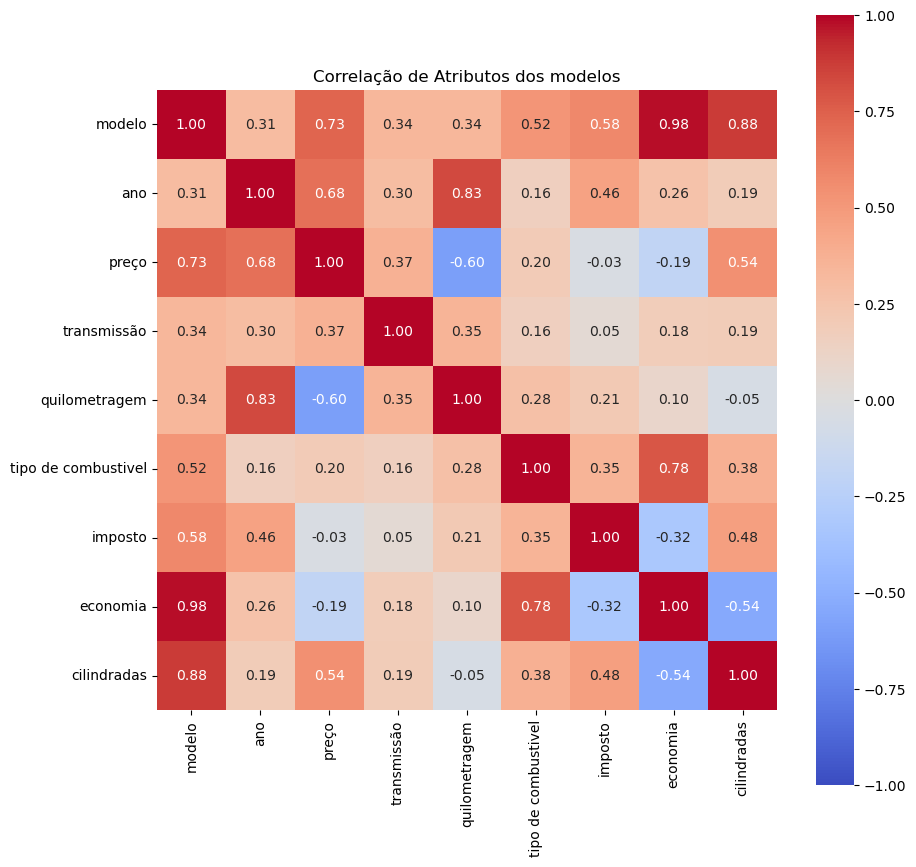

In [39]:
#plt.style.use('dark_background')

# Colunas categóricas
categorical_columns = ['modelo', 'ano', 'transmissão', 'tipo de combustivel']

# A função já calcula e plota automaticamente
result= associations(
    df_models,
    nominal_columns=categorical_columns,
    compute_only=False, # Gera o gráfico
    cmap='coolwarm',    # Mapa de cores 
    figsize=(10, 10), 
    title="Correlação de Atributos dos modelos"
)

# Também recuperamos os valores numéricos
corr_matrix = result['corr']

**Para interpretar estes resultados, vamos dividir em 5 categorias:**
- 0.00 a 0.19 - Muito Fraca	
- 0.20 a 0.39 - Fraca: Existe uma leve tendência, mas com muito ruído
- 0.40 a 0.59 - Moderada: Uma variável começa a explicar a outra
- 0.60 a 0.79 - Forte: Relação confiável
- 0.80 a 1.00 - Muito Forte: As vezes é a mesma informação mapeada de formas diferentes

In [40]:
# Transforma em valores absolutos (valores muito
# negativos indicam correlação inversamente proporcional)
corr_abs = corr_matrix.abs()

# Máscara para evitar repetição 
mask = np.triu(np.ones_like(corr_abs, dtype=bool), k=1)

# Transforma a matriz em uma lista de pares (coluna1, coluna2, valor)
corr_pairs = corr_abs.where(mask).stack().reset_index()
corr_pairs.columns = ['Feature_1', 'Feature_2', 'Correlation_Value']

# Define as fronteiras e os títulos
bins = [0.0, 0.20, 0.40, 0.60, 0.80, 1.0]
labels = ['Muito Fraco', 'Fraco', 'Moderado', 'Forte', 'Muito Forte']

# Aplica as fronteiras e títulos
corr_pairs['Strength'] = pd.cut(
    corr_pairs['Correlation_Value'], 
    bins=bins, 
    labels=labels, 
    include_lowest=True 
)

# Ordena os dados 
corr_pairs = corr_pairs.sort_values(by='Correlation_Value', ascending=False)

# Lista corrigida para usar as mesmas strings da variável 'labels' (ordem decrescente)
categories_to_print = ['Muito Forte', 'Forte', 'Moderado', 'Fraco', 'Muito Fraco']

for category in categories_to_print:
    print(f"\n=== CORRELAÇÃO {category.upper()} ===")
    
    # Filtra a categoria atual
    category_data = corr_pairs[corr_pairs['Strength'] == category]
    
    # Se a categoria não possui pares, deixa uma mensagem
    if category_data.empty:
        print("Não há pares nessa categoria.")
        continue
        
    for _, row in category_data.iterrows():
        feat1 = row['Feature_1']
        feat2 = row['Feature_2']
        val = row['Correlation_Value']
        print(f"[{val:.3f}] {feat1} <--> {feat2}")


=== CORRELAÇÃO MUITO FORTE ===
[0.980] modelo <--> economia
[0.879] modelo <--> cilindradas
[0.834] ano <--> quilometragem

=== CORRELAÇÃO FORTE ===
[0.782] tipo de combustivel <--> economia
[0.729] modelo <--> preço
[0.680] ano <--> preço
[0.601] preço <--> quilometragem

=== CORRELAÇÃO MODERADO ===
[0.580] modelo <--> imposto
[0.542] preço <--> cilindradas
[0.537] economia <--> cilindradas
[0.517] modelo <--> tipo de combustivel
[0.476] imposto <--> cilindradas
[0.455] ano <--> imposto

=== CORRELAÇÃO FRACO ===
[0.375] tipo de combustivel <--> cilindradas
[0.374] preço <--> transmissão
[0.355] transmissão <--> quilometragem
[0.353] tipo de combustivel <--> imposto
[0.342] modelo <--> quilometragem
[0.341] modelo <--> transmissão
[0.321] imposto <--> economia
[0.312] modelo <--> ano
[0.297] ano <--> transmissão
[0.281] quilometragem <--> tipo de combustivel
[0.259] ano <--> economia
[0.212] quilometragem <--> imposto

=== CORRELAÇÃO MUITO FRACO ===
[0.197] preço <--> tipo de combusti

**Insights interessantes:**
- Correlações muito fortes e fortes (preço e quilometragem são inversos);
- Correlações muito fracas (preço e imposto, quilometragem e economia)

#### Matriz de correlação das séries

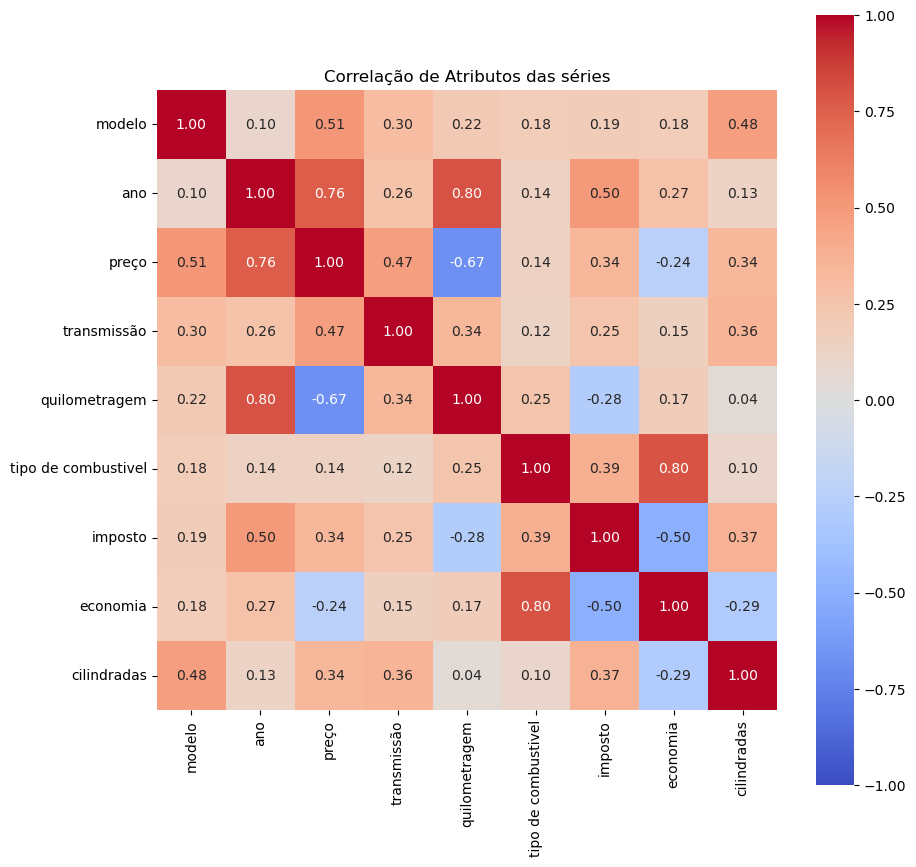


=== CORRELAÇÃO MUITO FORTE ===
[0.801] ano <--> quilometragem

=== CORRELAÇÃO FORTE ===
[0.795] tipo de combustivel <--> economia
[0.764] ano <--> preço
[0.672] preço <--> quilometragem

=== CORRELAÇÃO MODERADO ===
[0.511] modelo <--> preço
[0.500] imposto <--> economia
[0.499] ano <--> imposto
[0.475] modelo <--> cilindradas
[0.472] preço <--> transmissão

=== CORRELAÇÃO FRACO ===
[0.388] tipo de combustivel <--> imposto
[0.373] imposto <--> cilindradas
[0.359] transmissão <--> cilindradas
[0.343] preço <--> imposto
[0.341] preço <--> cilindradas
[0.336] transmissão <--> quilometragem
[0.298] modelo <--> transmissão
[0.294] economia <--> cilindradas
[0.277] quilometragem <--> imposto
[0.273] ano <--> economia
[0.265] ano <--> transmissão
[0.254] transmissão <--> imposto
[0.248] quilometragem <--> tipo de combustivel
[0.241] preço <--> economia
[0.218] modelo <--> quilometragem

=== CORRELAÇÃO MUITO FRACO ===
[0.195] modelo <--> imposto
[0.184] modelo <--> economia
[0.183] modelo <-->

In [41]:
# Colunas categóricas
categorical_columns = ['modelo', 'ano', 'transmissão', 'tipo de combustivel']

# A função já calcula e plota automaticamente
result= associations(
    df_series,
    nominal_columns=categorical_columns,
    compute_only=False, # Gera o gráfico
    cmap='coolwarm',    # Mapa de cores 
    figsize=(10, 10), 
    title="Correlação de Atributos das séries"
)

# Também recuperamos os valores numéricos
corr_matrix = result['corr']

# Transforma em valores absolutos (valores muito
# negativos indicam correlação inversamente proporcional)
corr_abs = corr_matrix.abs()

# Máscara para evitar repetição 
mask = np.triu(np.ones_like(corr_abs, dtype=bool), k=1)

# Transforma a matriz em uma lista de pares (coluna1, coluna2, valor)
corr_pairs = corr_abs.where(mask).stack().reset_index()
corr_pairs.columns = ['Feature_1', 'Feature_2', 'Correlation_Value']

# Define as fronteiras e os títulos
bins = [0.0, 0.20, 0.40, 0.60, 0.80, 1.0]
labels = ['Muito Fraco', 'Fraco', 'Moderado', 'Forte', 'Muito Forte']

# Aplica as fronteiras e títulos
corr_pairs['Strength'] = pd.cut(
    corr_pairs['Correlation_Value'], 
    bins=bins, 
    labels=labels, 
    include_lowest=True 
)

# Ordena os dados 
corr_pairs = corr_pairs.sort_values(by='Correlation_Value', ascending=False)

# Lista corrigida para usar as mesmas strings da variável 'labels' (ordem decrescente)
categories_to_print = ['Muito Forte', 'Forte', 'Moderado', 'Fraco', 'Muito Fraco']

for category in categories_to_print:
    print(f"\n=== CORRELAÇÃO {category.upper()} ===")
    
    # Filtra a categoria atual
    category_data = corr_pairs[corr_pairs['Strength'] == category]
    
    # Se a categoria não possui pares, deixa uma mensagem
    if category_data.empty:
        print("Não há pares nessa categoria.")
        continue
        
    for _, row in category_data.iterrows():
        feat1 = row['Feature_1']
        feat2 = row['Feature_2']
        val = row['Correlation_Value']
        print(f"[{val:.3f}] {feat1} <--> {feat2}")

### Boxplots

#### **Gráficos de caixa dos modelos**

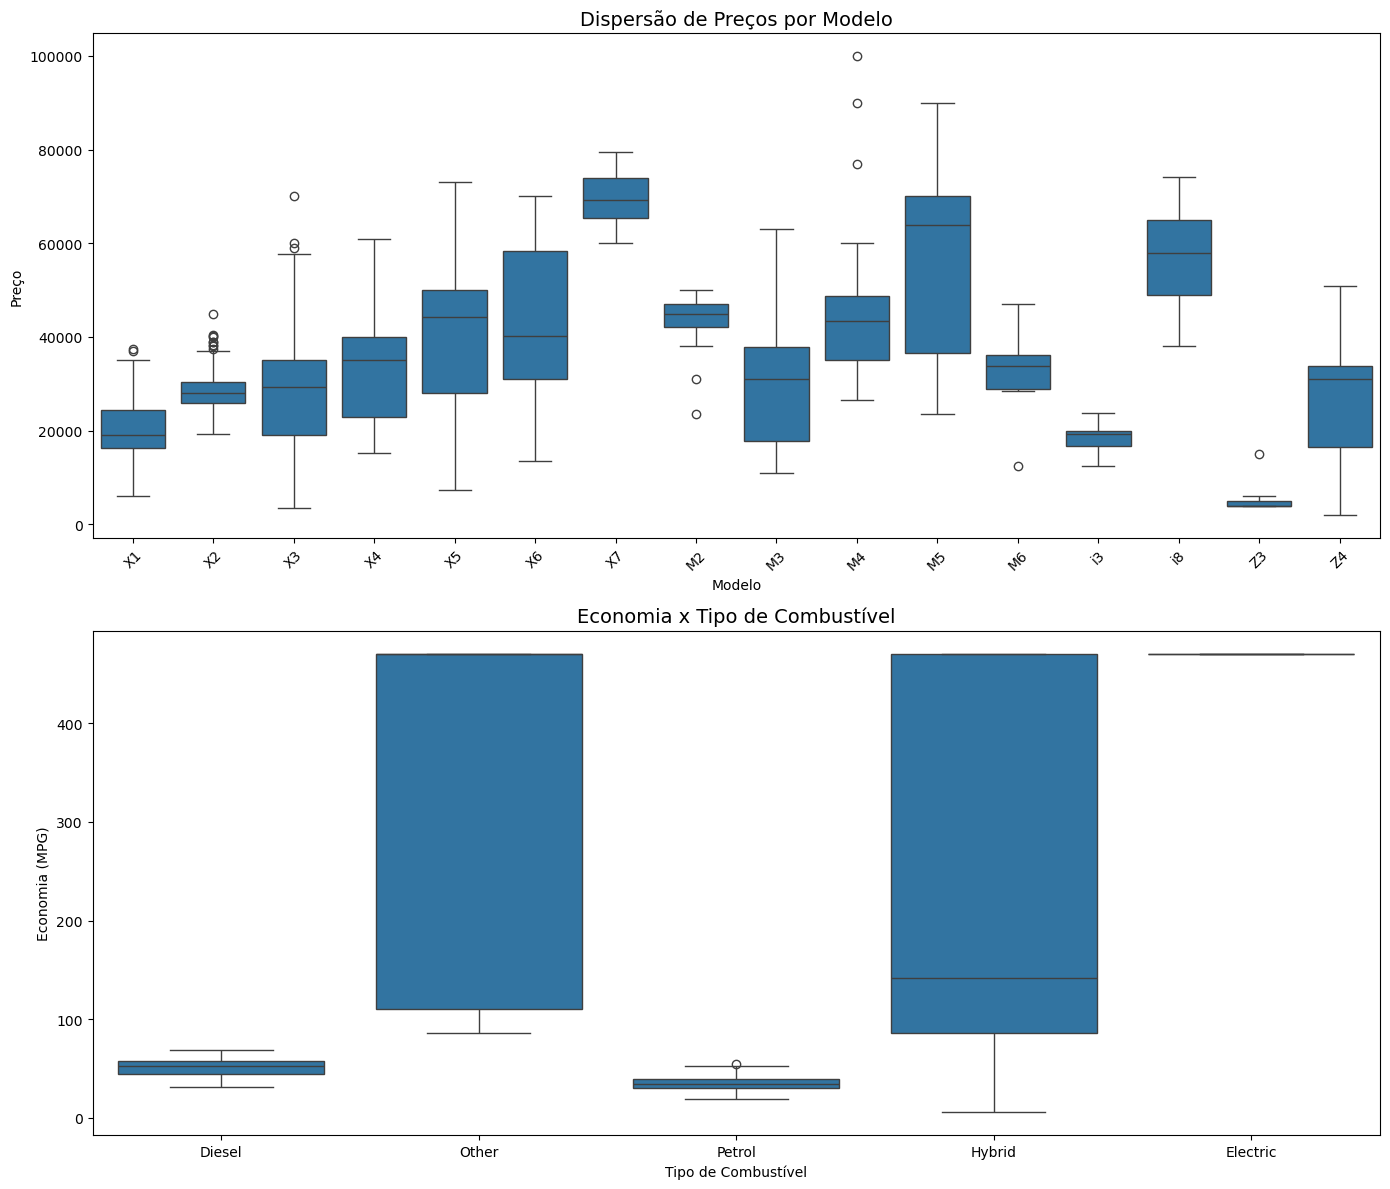

In [44]:
# plt.rcParams['figure.facecolor'] = '#121212'
# plt.rcParams['axes.facecolor'] = '#121212'

# Cria uma figura com espaço pra 2 gráficos
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(14, 12))

# Define a ordem 
model_order = [
    'X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 
    'M2', 'M3', 'M4', 'M5', 'M6', 
    'i3', 'i8', 
    'Z3', 'Z4'
]

# Preço x Modelo
sns.boxplot(
    data=df_models,
    x='modelo',
    y='preço',
    order=model_order,
    ax=axes[0]
)
axes[0].set_title('Dispersão de Preços por Modelo', color='#000000', fontsize=14)
axes[0].set_ylabel('Preço', color='#000000')
axes[0].set_xlabel('Modelo', color='#000000')

# Rotaciona os nomes dos modelos em 45 
axes[0].tick_params(axis='x', rotation=45) 

# Economia x Combustível 
sns.boxplot(
    data=df_models,
    x='tipo de combustivel',
    y='economia',
    ax=axes[1]
)
axes[1].set_title('Economia x Tipo de Combustível', color='#000000', fontsize=14)
axes[1].set_ylabel('Economia (MPG)', color='#000000')
axes[1].set_xlabel('Tipo de Combustível', color='#000000')

# Ajusta o espaçamento
plt.tight_layout()
plt.show()

#### **Gráficos de caixa das séries**

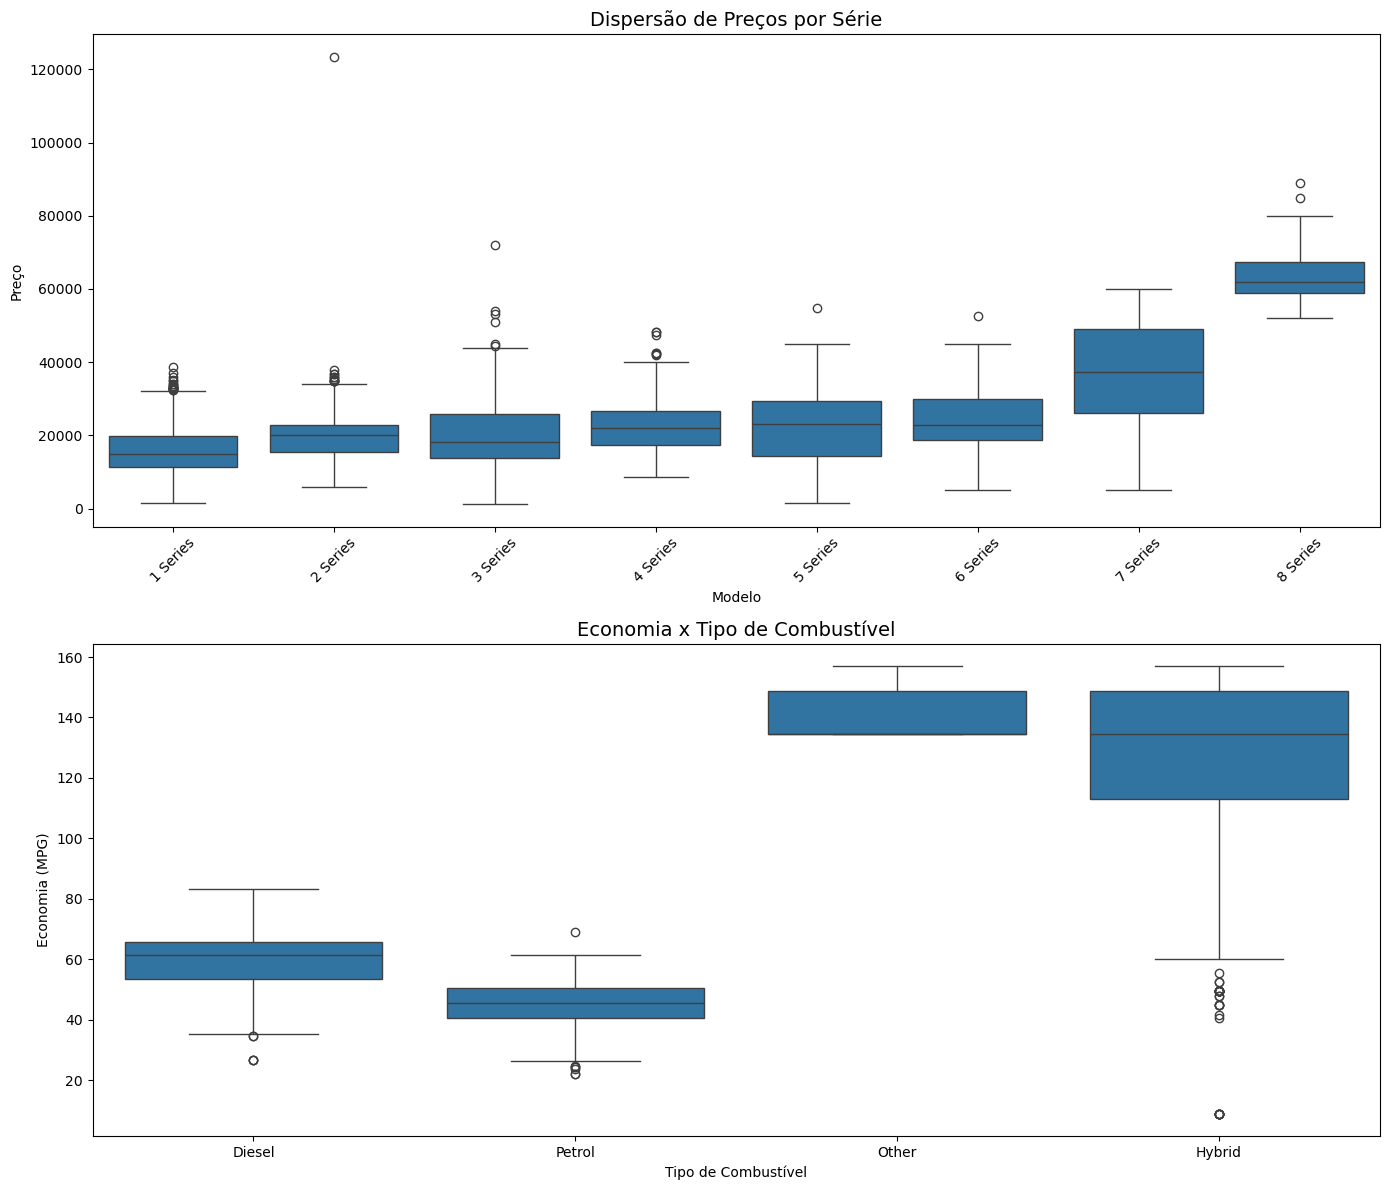

In [46]:
# plt.rcParams['figure.facecolor'] = '#121212'
# plt.rcParams['axes.facecolor'] = '#121212'

# Cria uma figura com espaço pra 2 gráficos
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(14, 12))

# Define a ordem 
series_order = [
    '1 Series', '2 Series', '3 Series', '4 Series',
    '5 Series', '6 Series', '7 Series', '8 Series'
]

# Preço x Modelo
sns.boxplot(
    data=df_series,
    x='modelo',
    y='preço',
    order=series_order,
    ax=axes[0]
)
axes[0].set_title('Dispersão de Preços por Série', color='#000000', fontsize=14)
axes[0].set_ylabel('Preço', color='#000000')
axes[0].set_xlabel('Modelo', color='#000000')

# Rotaciona os nomes dos modelos em 45 
axes[0].tick_params(axis='x', rotation=45) 

# Economia x Combustível 
sns.boxplot(
    data=df_series,
    x='tipo de combustivel',
    y='economia',
    ax=axes[1]
)
axes[1].set_title('Economia x Tipo de Combustível', color='#000000', fontsize=14)
axes[1].set_ylabel('Economia (MPG)', color='#000000')
axes[1].set_xlabel('Tipo de Combustível', color='#000000')

# Ajusta o espaçamento
plt.tight_layout()
plt.show()

### Scatterplots

#### **Scatterplot de Preço x Ano**

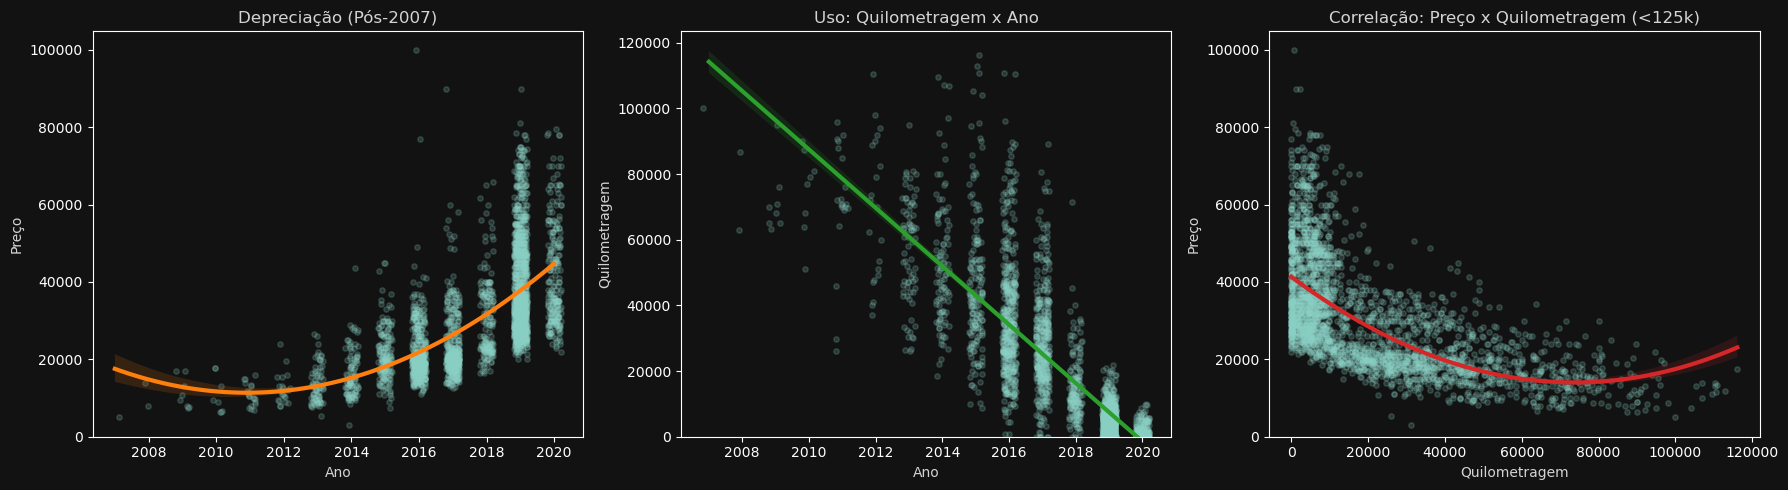

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# O FILTRO DE OURO: Criando o "Mercado Real"
# ==========================================
# Vamos manter apenas carros de 2007 em diante E com até 125.000 de quilometragem
df_filtrado = df_models[
    (df_models['ano'] >= 2007) & 
    (df_models['quilometragem'] <= 125000)
]

# Configurações visuais do Dark Mode
plt.style.use('dark_background')
plt.rcParams['figure.facecolor'] = '#121212'
plt.rcParams['axes.facecolor'] = '#121212'

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 5))

# --- GRÁFICO 1: Preço x Ano (Focado no Mercado Recente) ---
sns.regplot(
    data=df_filtrado,
    x='ano',
    y='preço',
    scatter_kws={'alpha': 0.2, 's': 15},
    line_kws={'color': '#ff7f0e', 'linewidth': 3}, 
    order=2,            
    x_jitter=0.2,       
    ax=axes[0]
)
axes[0].set_title('Depreciação (Pós-2007)', color='#d4d4d4', fontsize=12)
axes[0].set_ylabel('Preço', color='#d4d4d4')
axes[0].set_xlabel('Ano', color='#d4d4d4')
axes[0].set_ylim(bottom=0)

# --- GRÁFICO 2: Quilometragem x Ano ---
sns.regplot(
    data=df_filtrado,
    x='ano',
    y='quilometragem',
    scatter_kws={'alpha': 0.2, 's': 15},
    line_kws={'color': '#2ca02c', 'linewidth': 3},
    x_jitter=0.2,
    ax=axes[1]
)
axes[1].set_title('Uso: Quilometragem x Ano', color='#d4d4d4', fontsize=12)
axes[1].set_ylabel('Quilometragem', color='#d4d4d4')
axes[1].set_xlabel('Ano', color='#d4d4d4')
axes[1].set_ylim(bottom=0)

# --- GRÁFICO 3: Preço x Quilometragem (Até 125k) ---
sns.regplot(
    data=df_filtrado,
    x='quilometragem',
    y='preço',
    scatter_kws={'alpha': 0.2, 's': 15},
    line_kws={'color': '#d62728', 'linewidth': 3},
    order=2,            
    ax=axes[2]
)
axes[2].set_title('Correlação: Preço x Quilometragem (<125k)', color='#d4d4d4', fontsize=12)
axes[2].set_ylabel('Preço', color='#d4d4d4')
axes[2].set_xlabel('Quilometragem', color='#d4d4d4')
axes[2].set_ylim(bottom=0)

plt.tight_layout()
plt.show()

#### **Scatterplot de Quilometragem x Ano**

#### **Scatterplot de Quilometragem x Preço**

# a fazer
- scatterplot para verificar clusters
- verificar se média de preço segue normal
- algum ano teve mais vendas?
